# Video of spikes at neuron locations

Plot each neuron at its location and color points by whether the neuron spikes at a given timestep. First save each frame as a PNG, then assemble a video with OpenCV.

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import cv2
import shutil

from utils import graphics
from buryn_utils import location_utils, spikes_utils

graphics.set_matplotlib_settings()


In [26]:
BURYNOUTPUTS_DIR = '../data/buryn_data/buryn_outputs_01'
LOCATIONS_PATH_E = Path(BURYNOUTPUTS_DIR+'/locations/group_e_locations.txt')
LOCATIONS_PATH_I = Path(BURYNOUTPUTS_DIR+'/locations/group_i_locations.txt')
SPIKES_PATH_E = Path(BURYNOUTPUTS_DIR+'/recordings/spikes_e.txt')
SPIKES_PATH_I = Path(BURYNOUTPUTS_DIR+'/recordings/spikes_i.txt')
OUTPUT_VIDEO = Path(BURYNOUTPUTS_DIR+'/videos/spikes_locations_smoothed.mp4')
STEP_MIN = 0
STEP_MAX = 10000
FPS = 15
SMOOTHING_WINDOW = 1000
FRAME_COUNT = 100
RATE_CMAP = 'viridis'

for path in (LOCATIONS_PATH_E, LOCATIONS_PATH_I, SPIKES_PATH_E, SPIKES_PATH_I):
    if not path.exists():
        raise FileNotFoundError(f'Could not find {path.resolve()}')

In [27]:
neuron_ids_e, neuron_locations_e = location_utils.load_neuron_locations(LOCATIONS_PATH_E)
neuron_ids_i, neuron_locations_i = location_utils.load_neuron_locations(LOCATIONS_PATH_I)

spike_steps_e, neuron_ids_e_spikes = spikes_utils.load_spikes(SPIKES_PATH_E)
spike_steps_i, neuron_ids_i_spikes = spikes_utils.load_spikes(SPIKES_PATH_I)

spike_matrix_e = spikes_utils.build_spike_matrix(spike_steps_e, neuron_ids_e_spikes, STEP_MAX, len(neuron_locations_e))
print(spike_matrix_e.dtype)
spike_matrix_i = spikes_utils.build_spike_matrix(spike_steps_i, neuron_ids_i_spikes, STEP_MAX, len(neuron_locations_i))


print(f'Spike matrix E shape: {spike_matrix_e.shape}')
print(f'Spike matrix I shape: {spike_matrix_i.shape}')

bool
Spike matrix E shape: (2500, 10001)
Spike matrix I shape: (625, 10001)


In [28]:
window = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW
smoothed_spike_rates_e = np.apply_along_axis(
    lambda m: np.convolve(m, window, mode='same'),
    axis=1,
    arr=spike_matrix_e.astype(np.float32),
)
smoothed_spike_rates_i = np.apply_along_axis(
    lambda m: np.convolve(m, window, mode='same'),
    axis=1,
    arr=spike_matrix_i.astype(np.float32),
)

frame_steps = np.linspace(STEP_MIN, STEP_MAX, num=FRAME_COUNT, dtype=int)
frame_steps = np.unique(frame_steps)

print(f'Spike matrix E shape: {spike_matrix_e.shape}')
print(f'Smoothed spike rates E shape: {smoothed_spike_rates_e.shape}')
print(f'Spike matrix I shape: {spike_matrix_i.shape}')
print(f'Smoothed spike rates I shape: {smoothed_spike_rates_i.shape}')
print(f'Frame steps: {len(frame_steps)}')

Spike matrix E shape: (2500, 10001)
Smoothed spike rates E shape: (2500, 10001)
Spike matrix I shape: (625, 10001)
Smoothed spike rates I shape: (625, 10001)
Frame steps: 100


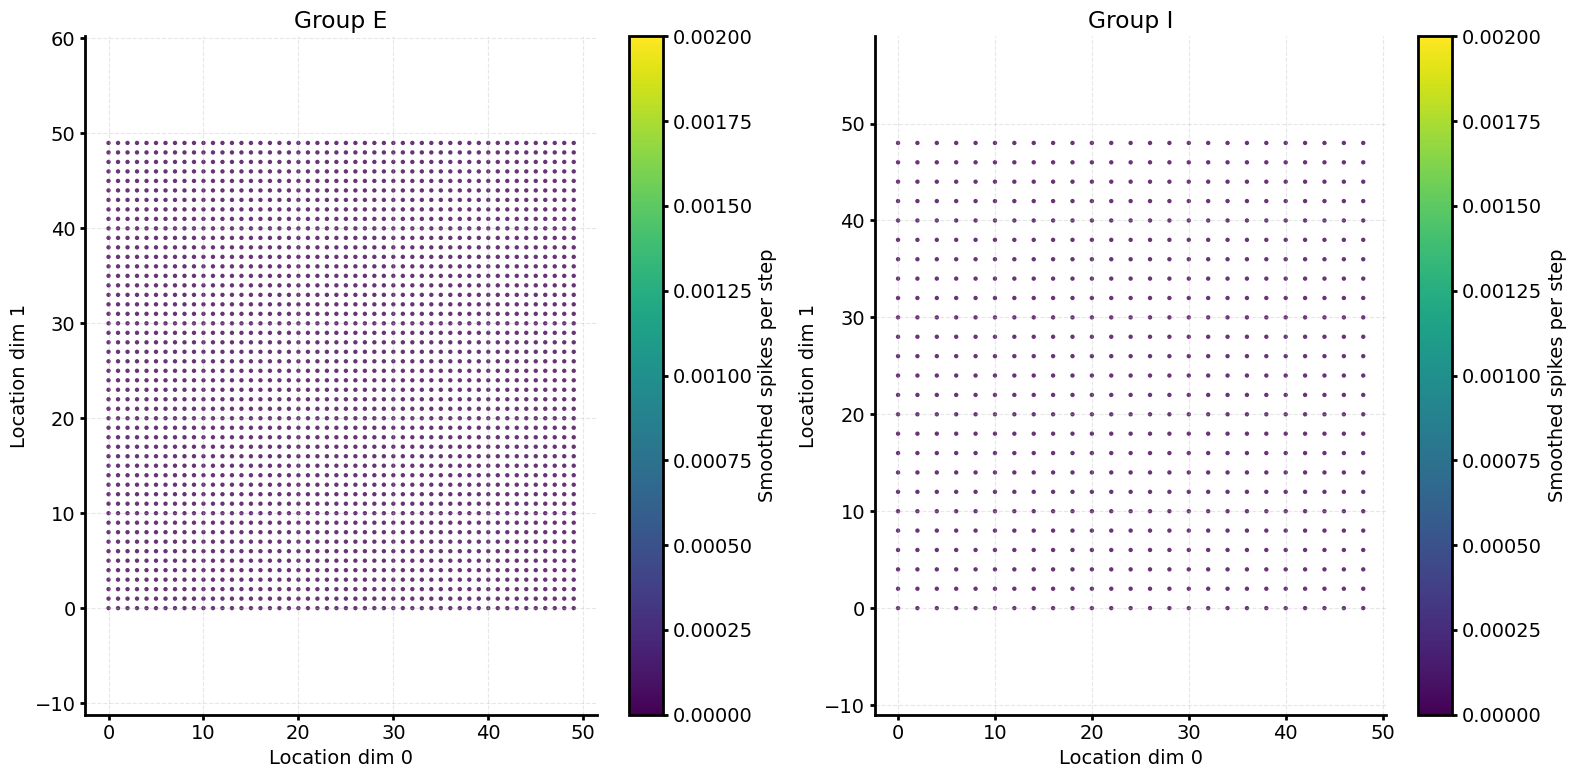

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
cmap = plt.get_cmap(RATE_CMAP)

rate_min_e = 0.0
rate_max_e = 0.002
norm_e = plt.Normalize(vmin=rate_min_e, vmax=rate_max_e)
colors_e = cmap(norm_e(smoothed_spike_rates_e[:, frame_steps[0]]))
scatter_e = axes[0].scatter(
    neuron_locations_e[:, 0],
    neuron_locations_e[:, 1],
    c=colors_e,
    s=10,
    alpha=0.8,
    edgecolors='none',
)

rate_min_i = 0.0
rate_max_i = 0.002
norm_i = plt.Normalize(vmin=rate_min_i, vmax=rate_max_i)
colors_i = cmap(norm_i(smoothed_spike_rates_i[:, frame_steps[0]]))
scatter_i = axes[1].scatter(
    neuron_locations_i[:, 0],
    neuron_locations_i[:, 1],
    c=colors_i,
    s=10,
    alpha=0.8,
    edgecolors='none',
)

axes[0].set_title('Group E')
axes[1].set_title('Group I')
for ax in axes:
    ax.set_xlabel('Location dim 0')
    ax.set_ylabel('Location dim 1')
    ax.axis('equal')
    ax.grid(True, linestyle='--', alpha=0.3)

cbar_e = fig.colorbar(plt.cm.ScalarMappable(norm=norm_e, cmap=cmap), ax=axes[0])
cbar_e.set_label('Smoothed spikes per step')
cbar_i = fig.colorbar(plt.cm.ScalarMappable(norm=norm_i, cmap=cmap), ax=axes[1])
cbar_i.set_label('Smoothed spikes per step')

In [30]:
scatter_e.set_cmap(cmap)
scatter_e.set_norm(norm_e)
scatter_i.set_cmap(cmap)
scatter_i.set_norm(norm_i)
fig.canvas.draw()
w, h = fig.canvas.get_width_height()  # pixels

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, FPS, (w, h))

for frame in frame_steps:
    rates_e = smoothed_spike_rates_e[:, frame]
    rates_i = smoothed_spike_rates_i[:, frame]
    scatter_e.set_array(rates_e)
    scatter_i.set_array(rates_i)
    axes[0].set_title(f"Group E (step {frame})")
    axes[1].set_title(f"Group I (step {frame})")

    # Draw and grab pixels from the canvas (no files written)
    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)

    # Convert RGBA -> BGR for OpenCV
    bgr = cv2.cvtColor(buf, cv2.COLOR_RGBA2BGR)
    video.write(bgr)

video.release()
print(f"Saved video to {OUTPUT_VIDEO.resolve()}")

Saved video to /home/hi/coding/buryn-simulation/data/buryn_data/buryn_outputs_01/videos/spikes_locations_smoothed.mp4
